# Model

In [79]:
from acceptor_TI import Problem, ModelOptions, Geometry, TightBindingEdge

data_path = "../../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [80]:
SO_coupling = 0.1

In [81]:
sub_1 = ["A", "B"]
sub_2 = ["B", "A"]
for sub_label, nn_label in zip(sub_1, sub_2):
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    parser["nn_hopping"][nn_label]["t_ss_sigma"] = -1
    parser["nn_hopping"][nn_label]["t_sp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_pi"] = -1.4
    parser["SO_coupling"][sub_label]["lambda_pp"] = SO_coupling

In [82]:
location = "edge"

# Setup
problem.model_options = ModelOptions(10, 200, location, "reduced")
problem.geometry = Geometry(model_options=problem.model_options, cell_parser=problem.cell_parser)
problem.geometry.build_lattice()

problem.hamiltonian[location]["tight_binding"] = TightBindingEdge(
                model_options=problem.model_options, cell_parser=problem.cell_parser)
tight_binding:TightBindingEdge = problem.hamiltonian[location]["tight_binding"]
tight_binding.orbitals = ['s', 'p_z']
tight_binding.n_orbitals = 2

Building Geometry...
Geometry - Done.


In [83]:
problem.model_options.solve_connectivity = False

In [84]:
import numpy as np
from sympy.physics.quantum.cg import CG
def _clebsch_gordan(tb:TightBindingEdge):
        tb.CG_coefficients = {}
        j_2 = 1/2
        m_2 = np.arange(-j_2, j_2 + 1, 1)
        for j_1 in [0, 1]:          
            m_1 = np.arange(-j_1, j_1 + 1, 1)
            j_3 = j_1 + j_2
            m_3 = np.arange(-j_3, j_3 + 1, 1)
            for i, m_j in enumerate(m_3):
                for m_l in m_1:
                    if m_l in [1, -1]: # NOTE: remove p_x and p_y states
                        continue
                    for m_s in m_2:
                        state = f"|{j_1},{m_l};{j_2},{m_s}>"
                        if (m_l + m_s) != m_j:
                            continue
                        tb.CG_coefficients[state] = CG(j_1, m_l, j_2, m_s, j_3, m_j).doit()

In [85]:
_clebsch_gordan(tight_binding)
tight_binding.build_hamiltonian(geometry=problem.geometry)

Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [86]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...


'Edge' Eigenvalues - Done.


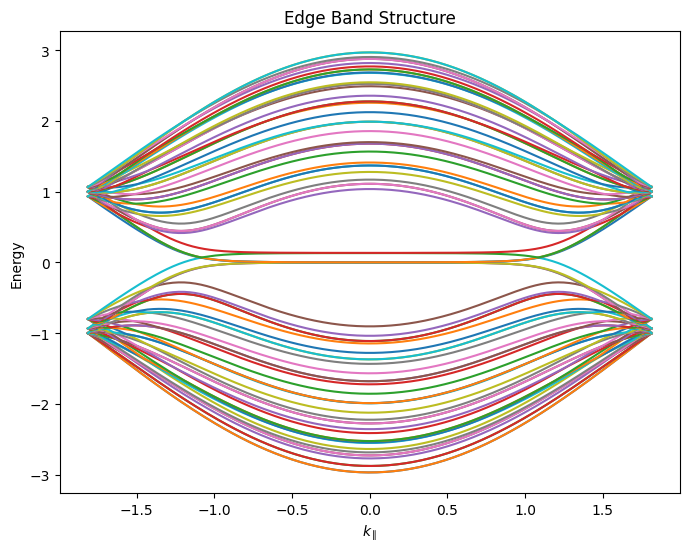

In [87]:
problem.plot(plot_type="dispersion", location=location)

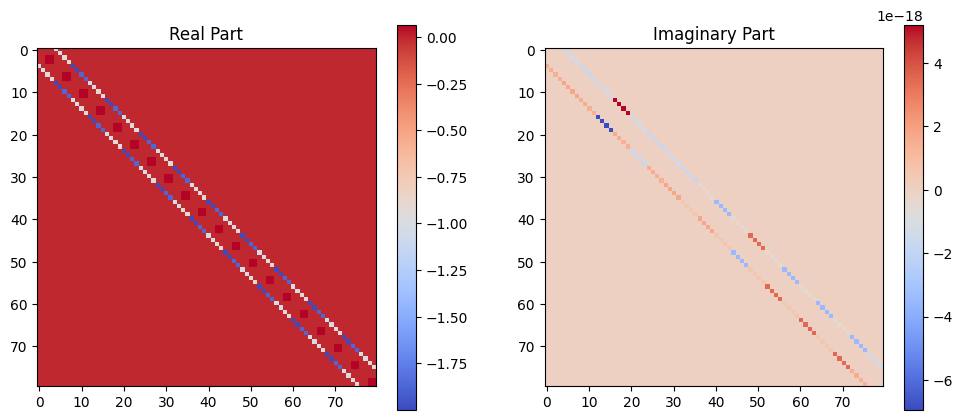

In [88]:
tb = problem.hamiltonian["edge"]["tight_binding"]
g = problem.geometry
k = g.k_edge[int(g.N_k/2) - 1]
H_k = tb._fourier_transform(g, k)
tb._visualise_matrix(H_k)